In [ ]:
import numpy as np 
import pandas as pd 
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Ignorer tous les avertissements (utilisez avec précaution)
warnings.filterwarnings("ignore")

In [11]:
file_path = r"C:\Users\F1302\Desktop\Travail éfféctué Stage\Data\DATASET_stage_total 2.0.xlsm"
sheet_name = 'TAB'
data = pd.read_excel(file_path, sheet_name=sheet_name)

# Contexte de l'etude

La division Sécurité Adhérence des Pistes, avec l’aide du laboratoire d’essai et d’expertise, a réalisé en janvier 2023 une campagne de mesures d’adhérence opérationnelle sur l’aérodrome de Mont-Dauphin - Saint-Crépin. Cette initiative s’inscrit dans une démarche de recherche et développement visant à améliorer les performances de freinage des avions sur piste contaminée. Elle fait partie intégrante des programmes de recherche liés à la « modélisation des performances de freinage avion à partir de mesures d’adhérence sur chaussée contaminée hivernale ». L’objectif est de déterminer l’effort de freinage optimal pour les avions en fonction de l’état de surface de la piste. Cette mission novatrice a également permis de mieux comprendre et maîtriser le comportement des machines de mesure d’adhérence sur chaussée contaminée. L’ambition est de réitérer cette expérience à plus grande échelle en 2024, au Canada.

## Pourquoi modéliser le CFL C

Le coefficient de frottement longitudinal (CFL) est le rapport entre la force de frottement ralentissant le pneumatique et la force verticale appliquée à la roue. Il peut être comparé au coefficient de frottement de Coulomb, qui décrit la résistance au glissement entre deux surfaces en contact:  

<div style="text-align: center;">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRccmsHyGdHND7fWyrqAevCuXvb8TfhVIsgIQ&s" alt="Slip ratio vs friction" width="600"/>
</div>


L'adhérence des pneumatiques d'un avion à la piste est cruciale pour plusieurs raisons :
1. **Freinage à l'atterrissage :** Une bonne adhérence permet de réduire la distance de freinage et d'assurer un arrêt en toute sécurité.
2. **Décollage interrompu :** En cas de besoin d'interrompre un décollage, une adhérence adéquate assure que l'avion puisse s'arrêter avant la fin de la piste.
3. **Mise en rotation des roues à l'impact :** Lors de l'atterrissage, l'adhérence permet aux roues de se mettre en rotation rapidement pour éviter l'usure excessive des pneumatiques.
4. **Contrôle directionnel au roulage :** Une bonne adhérence est nécessaire pour maintenir le contrôle de la direction de l'avion pendant le roulage, surtout dans des conditions de piste contaminée ou glissante.

La mesure la plus précise pour évaluer l'adhérence des avions sur une chaussée dans des conditions spécifiques est celle du coefficient de frottement longitudinal (CFL). Cette mesure est réalisée à travers des essais rigoureux, où divers points de fonctionnement sont testés en faisant varier la vitesse et le taux de freinage. 



Pour chaque passage (avec la même valeur de vitesse consigne, de glissement consigne et pour le même contaminant), le trajet est divisé en partitions de 20 mètres. Pour chaque mètre de chaque partition, le coefficient de frottement longitudinal (CFL) est mesuré. À la fin de chaque partition, les valeurs moyennes et les écarts types du CFL, ainsi que de la vitesse, du glissement et de la masse sont calculés. La vitesse et le glissement doivent être centrés sur les valeurs consignées.

La stabilité de la masse est également mesurée, en tenant compte du fait que la mesure est effectuée avec un seul moyeu appliquant une masse de 180 kg. Les différents contaminants provoquent des secousses du véhicule, ce qui entraîne une variabilité de la masse, qui doit être centrée sur 180 kg.

Ces mesures de stabilité sont cruciales pour garantir la répétabilité et la reproductibilité des essais, aspects qui seront abordés dans la suite de ce rapport.

## Description des variables

In [ ]:
data.columns

Index(['Machine', 'Pneumatique', 'Vitesse', 'Nom du Curseur',
       'Seuil de départ', 'Position/Axe', 'Décalage/Axe', 'Date', 'Date_txt',
       'Heure', 'Heure_txt', 'Glissement', 'Pas Min [m]', 'Pas Max [m]',
       'Moyenne Vitesse [Km/h]', 'Moyenne CFL F', 'Moyenne CFL C',
       'Moyenne G% [%]', 'Fv (kg)', 'ET G%', 'Ic G%', 'Tsurf (V)', 'ET CFLF',
       'ET CFLC', 'Ic CFL C', 'ET Fv', 'Ic Fv', 'T° BDR (V)', 'Contaminant',
       'hauteur (mm)', 'Test'],
      dtype='object')

In [ ]:
data["Contaminant"].unique()

array(['Neige fraiche (B)', 'Neige fraiche (G)', 'N.C. (G)', '-',
       'N.C. (B)', 'NC.C.', 'Verglas', nan, 'DRY', 'Glace', 'SLUSH'],
      dtype=object)

### Base de Données Initiale

La base de données initiale comprend 31 variables et 2236 observations. Ces variables se répartissent en plusieurs catégories :

1. **Variables liées au moyen de mesure :**
   - **Machine de mesure :** IMAG 208 G 117
   - **Nature du pneumatique :** Pneu rainuré PEX Mt St Dauphin

2. **Informations sur la piste de mesure :**
   - **Nom de curseur :** Identifiant de la section de piste, la section numéro i est nommée Cm (avec m = 20 * (i-1))
   - **Seuil de départ :** Indique le côté de début de mesure 
   - **Position par rapport à l’axe :** Indique si la mesure est effectuée à droite ou à gauche de l’axe de la piste
   - **Décalage par rapport à l’axe :** Distance latérale par rapport à l’axe central (dans cette base de donnée le décalage est toujours 0)
   - **Intervalles de chaque passage :** Distance minimale et maximale en mètres pour chaque passage, pour un curseur C100 le pas min c'est 100, le pas max est 120

3. **Variables temporelles :**
   - **Date et heure exacte de mesure**

4. **Variables de mesure :**
   - **Vitesse**: les valeurs sont cetrées sur 40 ou 65
   - **Moyenne du glissement** :  prend des valeur entre 0\% et 100%
   - **Masse du véhicule pour chaque observation**
   - **Température de surface**:  vue qu'on travaille sur des conditions hevernale, les températures sont négatives (entre -24 et -11 degrér C)
   - **Température de bande de roulement**: les températures varient de -1 à 13 degrér C
   - **Nature du contaminant**: il y a 9 types de contaminant; Neige fraiche (B), Neige fraiche (G), N.C. (G', N.C. (B), NC.C., Verglas, DRY, Glace, SLUSH
   - **Hauteur du contaminant (en mm)**: Chaque contaminant à une hauteur unique

5. **Variables de frottement :**
   - **Coefficient de frottement longitudinal (CFL C) :** Mesure de la force de freinage appliquée par le pneumatique sur la surface de la piste.
   - **Force de frottement (CFL F) :** Mesure de la force de freinage générée par le cumul du contaminant après la roue. Cette mesure sert de référence lorsque la surface est sèche et sans contaminant, où CFL C devrait être égal à CFL F.

### Mesures de Stabilité

En outre, des mesures de stabilité (écart type et incertitude) ont été effectuées pour les valeurs suivantes :
   - **CFL C**
   - **CFL F**
   - **Glissement**
   - **Masse**

Ces mesures de stabilité sont essentielles pour garantir la répétabilité et la reproductibilité des essais, aspects qui seront détaillés dans la suite de ce rapport.

# Préparation de la table de données

Dans un projet de data science la préparation des données est crucial pour assurer la fiabilité des résultats. 

En éliminant les erreurs, les valeurs aberrantes et en gérant les données manquantes, on garantit la qualité des données utilisées pour l'analyse. Ce processus permet également de préparer les données en vue de la modélisation, en assurant une cohérence et une précision optimales.

In [27]:
column_to_keep = ['Vitesse',  'Date', 'Heure', 'Glissement',
       'Moyenne Vitesse [Km/h]', 'Moyenne CFL F', 'Moyenne CFL C',
       'Moyenne G% [%]', 'Fv (kg)', 'ET G%', 'Ic G%', 'Tsurf (V)', 'ET CFLF',
       'ET CFLC', 'Ic CFL C', 'ET Fv', 'Ic Fv', 'T° BDR (V)', 'Contaminant',
       'Test']

In [42]:
df = data[column_to_keep].copy()
df1 = df.copy()
df.shape

(2236, 20)

## Nettoyage des Données

Certaines valeurs de CFL C sont négatives (une valeur très petite tendant vers 0). Dans ce cas, ces valeurs seront transformées en 0, puisque les valeurs de CFL C doivent être comprises entre 0 et 1. De plus, les valeurs manquantes seront supprimées de la base de données.

In [43]:
df1 = df1.dropna(axis = 0)
df1 = df1[df1.Contaminant != '-']
df1.loc[df1['Moyenne CFL C'] < 0, 'Moyenne CFL C'] = 0

In [45]:
df1.shape

(2133, 20)

In [46]:
df1.Contaminant.value_counts()

Contaminant
NC.C.                540
Neige fraiche (B)    337
Neige fraiche (G)    306
N.C. (G)             217
N.C. (B)             217
Glace                180
SLUSH                168
Verglas              120
DRY                   48
Name: count, dtype: int64

Dans la base de données initiale, 103 valeurs étaient manquantes pour la variable "contaminant". Après avoir supprimé toutes les valeurs manquantes, le jeu de données final comporte 2133 observations. Cela correspond à la taille initiale du jeu de données diminuée de 103.


## Validation des observations


Avant de faire une analyse exploratoire de toute notre base de données, il faut tout d'abord définir un critère de validité des observations, c'est à dire supprimer les observations ayant une valeur moyenne de glissement ou de masse qui est instable (pour la variable cible, on va la traiter aprées).

### Importance de Définir un Critère de Stabilité

Définir un critère de stabilité est essentiel pour garantir la fiabilité des mesures et des analyses. Comme on peut le voir dans l'exemple suivant, illustré par l'image ci-dessous, les petites valeurs de glissement peuvent entraîner de fortes variations dans le coefficient de frottement longitudinal (CFL).

**Exemple Illustratif**
Pour le contaminant "glace", sur une section de 20 mètres :

    Glissement moyen : 3%
    Incertitude : 1.5%
    Variation du CFL : de 0 à 0.2 (le CFL varie entre 0 et 1)

Ces valeurs montrent une grande dispersion, ce qui signifie que les mesures de CFL pour ces petites valeurs de glissement sont peu fiables et doivent être invalidées.

En revanche, pour une valeur de glissement de 60% avec une incertitude de 10% :

    Variation du CFL : de 0.16 à 0.18

Ici, même une grande variation dans le glissement entraîne une variation non significative du CFL, indiquant des mesures plus stables et fiables.
<div style="text-align: center;">
  <img src="https://www.researchgate.net/profile/Pedro-Do-Carmo/publication/352259201/figure/fig3/AS:1032839982223360@1623259649621/Slip-ratio-versus-friction-coefficient.png" alt="Slip ratio vs friction" width="500"/>
</div>




**Critère de Stabilité**

Pour les raisons précedentes, il est crucial de déterminer un critère de stabilité plus strict pour les petites valeurs de glissement par rapport aux grandes valeurs. Le seuil de validation doit être adapté en fonction de la valeur de glissement afin de s'assurer que les mesures de CFL soient fiables et représentatives des conditions réelles.
En plus des critères de stabilité pour le glissement et le coefficient de frottement longitudinal (CFL), il est également important de définir des tolérances pour la masse. Voici les points essentiels à considérer :

**Incertitude de la Masse**  

Pour la masse, il est toléré de prendre une valeur d'incertitude dépassant 15 kg. Cette tolérance est acceptable car l'incertitude de la masse n'a pas d'impact significatif sur le coefficient de frottement longitudinal (CFL C).
Centrage de la Masse

Il est également exigé que la moyenne des masses soit centrée sur 180 kg. Garantissant ainsi une uniformité dans les conditions de test.

**Importance de Ces Seuils**

    Précision des Mesures : Assurer que les mesures du coefficient de frottement longitudinal (CFL C) sont cohérentes et fiables.
    Adaptabilité : Permettre une adaptation flexible aux différentes conditions rencontrées sur les pistes contaminées.
    Fiabilité des Analyses : Garantir que les analyses reposent sur des données robustes et représentatives des conditions réelles.        


### Critère de Stabilité et Définition des Seuils

Pour garantir des mesures fiables et représentatives, il est essentiel de définir des seuils spécifiques de stabilité pour chaque contaminant et pour chaque intervalle de valeur du glissement. Voici comment cela peut être structuré :


**Définition des Seuils**

    Adaptation au Contaminant :
        Chaque type de contaminant (par exemple, neige, glace, etc) a des caractéristiques différentes qui influencent le coefficient de frottement longitudinal (CFL C). Par conséquent, les seuils de stabilité doivent être adaptés en fonction du contaminant testé.

    Intervalle de Valeur du Glissement :
        Les seuils de stabilité doivent également varier en fonction des intervalles de valeur du glissement. Pour les petites valeurs de glissement, des seuils plus stricts sont nécessaires pour garantir la précision des mesures. Pour les grandes valeurs de glissement, une tolérance plus grande peut être acceptable.

    Validation par un Physicien
        Le choix de la discrétisation des intervalles de glissement et des seuils est déterminé par des outils statistiques (analyse des distributions, étude des dispersions, effets marginaux, etc.). L'objectif est de trouver un compromis entre la quantité et la qualité des données, en privilégiant la qualité. Finalement, tous ces choix doivent être validés par un expert; sinon, le travail doit être repris.



# Determination des Seuils

Si l'une des conditions suivantes est remplie :

    L'intervalle de confiance du pourcentage de glissement (ICg%ICg%​) dépasse le seuil seuilgseuilg​
    L'intervalle de confiance de la force verticale (ICFvICFv​) dépasse le seuil seuilFvseuilFv​
    La différence absolue entre 180 kg et la force verticale (∣180−Fv∣∣180−Fv∣) dépasse le seuil seuil180seuil180​

Alors, l'observation est refusée. Sinon, l'observation est validée.

Dans ce qui suit, trois variables contenant chacune un critère seront examinées. Les seuils seront finalement choisis afin de trouver un compromis entre la quantité et la qualité de notre base de données, en privilégiant la qualité.


In [ ]:
data_seuil = data.copy()
columns_to_keep2 = ['Vitesse', 'Glissement','Fv (kg)','Contaminant','Moyenne G% [%]',"ET G%",'Ic G%', 'Ic Fv']
data_seuil = data_seuil[columns_to_keep2]

In [ ]:
data_seuil.head()


,Vitesse,Glissement,Fv (kg),Contaminant,Moyenne G% [%],ET G%,Ic G%,Ic Fv
0,40,2,180.335652,Neige fraiche (B),2.518261,2.079551,0.969994,14.433277
1,40,2,183.004286,Neige fraiche (B),1.908095,0.989948,0.461755,11.614042
2,40,2,182.492381,Neige fraiche (B),2.076667,1.785212,0.832701,17.341270
3,40,2,179.842381,Neige fraiche (B),2.527143,1.716191,0.800507,13.576486
4,40,2,180.776190,Neige fraiche (B),1.860000,0.968380,0.451695,12.785137


In [ ]:
data_seuil["180 - Fv"] = (180 - data_seuil['Fv (kg)']).abs()

## Verglas (120 obseravations)

### Critère 1 (< seuil)

In [ ]:
def seuil(x):
    if x < 10:
        return 0.8
    elif x < 20:
        return 1.8
    else:
        return 5

In [ ]:
verglas = data_seuil[(data_seuil.Contaminant == "Verglas")].drop("Contaminant",axis=1)
verglas["seuil"] = verglas["Moyenne G% [%]"].apply(seuil)


Pour le contaminant verglas, les seuils de validation sont définis en fonction de la moyenne du pourcentage de glissement (\(G\%\)). Lorsque \(G\%\) est inférieur à 10, un seuil strict de 0.8 est appliqué pour assurer une haute précision. Par exemple, si la moyenne du glissement est de 8%, alors le seuil de 0.8 garantit que seules les mesures très précises seront acceptées, c'est-à-dire que seules les valeurs comprises entre 7.2% et 8.8% seront considérées valides.

Pour \(G\%\) entre 10 et 20, le seuil est de 1.8, permettant une tolérance modérée. Par exemple, si la moyenne du glissement est de 15%, un seuil de 1.8 permet une certaine variabilité tout en maintenant des mesures fiables, donc les valeurs comprises entre 13.2% et 16.8% seront acceptées.

Enfin, pour \(G\%\) supérieur à 20, le seuil est relâché à 5, acceptant de plus grandes variations car elles ont un impact moins significatif sur le coefficient de frottement. Par exemple, si la moyenne du glissement est de 80%, un seuil de 5 tolère une plus grande variabilité, acceptant les valeurs comprises entre 75% et 85%.

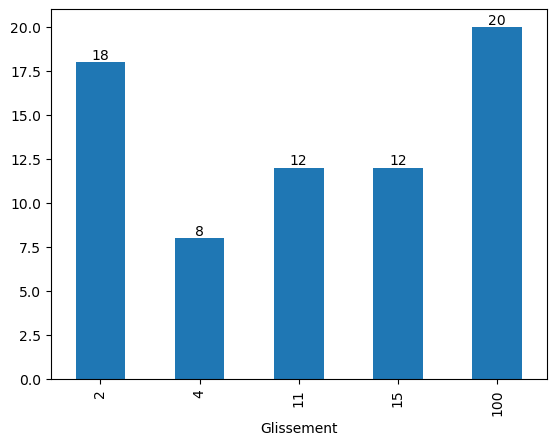

In [ ]:
count_df = verglas[verglas["Ic G%"] < verglas["seuil"]].groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

In [ ]:
verglas[verglas["Ic G%"] < verglas["seuil"]].shape

(70, 9)

### Critère 2 (20)

<function matplotlib.pyplot.show(close=None, block=None)>

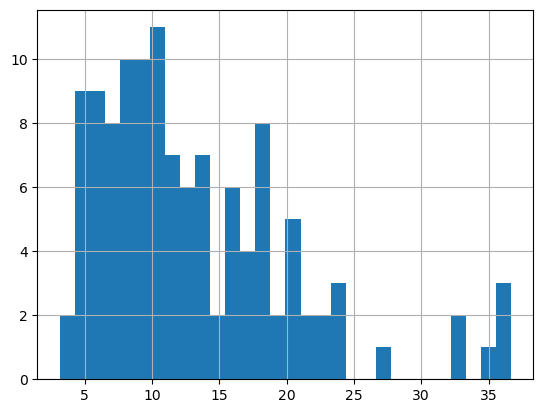

In [ ]:
verglas["Ic Fv"].hist(bins = 30)
plt.show

In [ ]:
verglas[verglas["Ic Fv"] > 20].shape

(19, 9)

Pour le deuxieme critère on va se permetre à un seuil de 20

### Critère 3 (6.1)

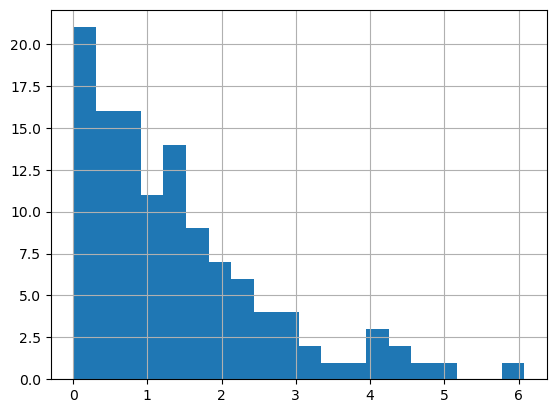

In [ ]:
verglas["180 - Fv"].hist(bins = 20)
plt.show()

Pour le troisieme critere on va choisir 6.1

### filtre de validité de verglas
Un critère finale de validité de verglas est: IC g% < seuil et  IC Fv < 20  et  |180 - Fv|  < 6.1  

In [ ]:
verglas.Vitesse.value_counts()

Vitesse
40    60
65    60
Name: count, dtype: int64

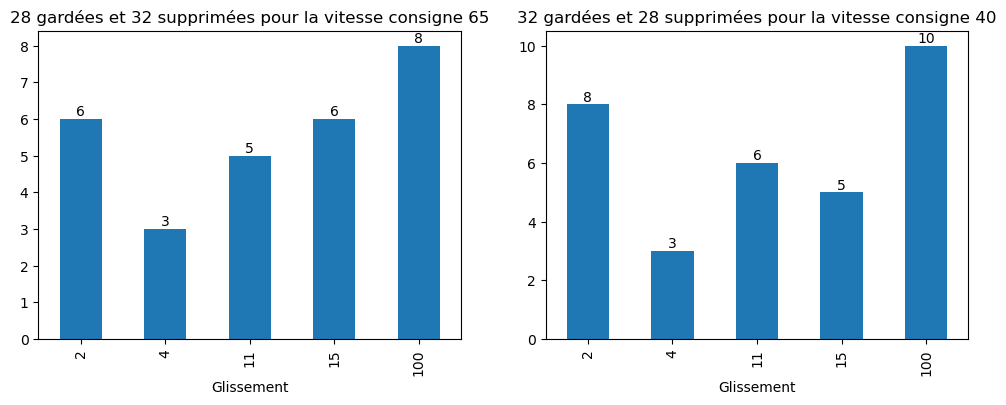

In [ ]:
filtre_1 = (verglas["Ic G%"] < verglas["seuil"]) & (verglas["Ic Fv"] < 20) & (verglas["180 - Fv"] < 6.1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
verglas_filtre=verglas[verglas.Vitesse == 65][filtre_1]
count_df = verglas_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{verglas_filtre.shape[0]} gardées et {60 -verglas_filtre.shape[0]} supprimées pour la vitesse consigne 65")
plt.subplot(1,2,2)
verglas_filtre=verglas[verglas.Vitesse == 40][filtre_1]
count_df = verglas_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points',)
plt.title(f"{verglas_filtre.shape[0]} gardées et {60 -verglas_filtre.shape[0]} supprimées pour la vitesse consigne 40")
plt.savefig('nom_de_l_image.png', dpi=300, bbox_inches='tight')

plt.show()


Validation des Observations en Présence du contaminant Verglas

Pour le premier contaminant, le verglas, représentant 120 observations dans la base de données initiale, les seuils de validation du glissement sont définis en fonction de la moyenne du pourcentage de glissement (G%).

    Pour G% inférieur à 10 : Un seuil strict de 0,8 est appliqué pour assurer une haute précision. Par exemple, avec une moyenne de glissement de 8%, seules les valeurs entre 7,2% et 8,8% seront considérées comme valides.

    Pour G% entre 10 et 20 : Un seuil de 1,8 est utilisé pour permettre une tolérance modérée. Par exemple, avec une moyenne de glissement de 15%, les valeurs comprises entre 13,2% et 16,8% seront acceptées.

    Pour G% supérieur à 20 : Le seuil est relâché à 5, acceptant de plus grandes variations. Par exemple, avec une moyenne de glissement de 80%, les valeurs entre 75% et 85% seront acceptées.

Autres Critères de Validation

    Pour le deuxième critère : Un seuil de 20 est appliqué. Par exemple, si la masse est centrée sur 175 kg, les observations entre 155 kg et 195 kg seront validées.

    Pour le troisième critère : Un seuil de 6,1 est choisi. Les valeurs de moyenne des masses entre 178,9 kg et 186,1 kg seront tolérées.

Résultats de l'Application des Seuils

Après application de ces seuils, 60 des 120 observations initiales ont été supprimées pour le contaminant verglas, réduisant ainsi la moitié des données. Cependant, la qualité des données est privilégiée sur leur quantité, garantissant des mesures plus fiables.

## SLUSH (168 observations)


### Critère 1 ( < seuil)

In [ ]:
def seuil(x):
    if x < 3:
        return 0.5
    if x < 10:
        return 1.35 #ancien 1.1
    elif x < 20:
        return 2 #ancien 1.9
    else:
        return 5
seuil_slh = lambda x:0.5 if x<3 else (1.1 if x<10 else (1.9 if x<20 else 5))


In [ ]:
slush = data_seuil[(data_seuil.Contaminant == "SLUSH")].drop("Contaminant",axis=1)
slush["seuil"] = slush["Moyenne G% [%]"].apply(seuil)

Les seuils choisis sont de 0.5 pour des glissements inférieurs à 3%, de 1.1 pour des glissements entre 3% et 10%, de 1.9 pour des glissements entre 10% et 20%, et de 5 pour des glissements supérieurs à 20%. Par exemple, pour une moyenne de glissement de 5%, le seuil strict de 0.5 garantit une haute précision, tandis qu'un seuil de 5 pour un glissement de 60% permet d'accepter des variations importantes, nécessaires pour les glissements élevés. 

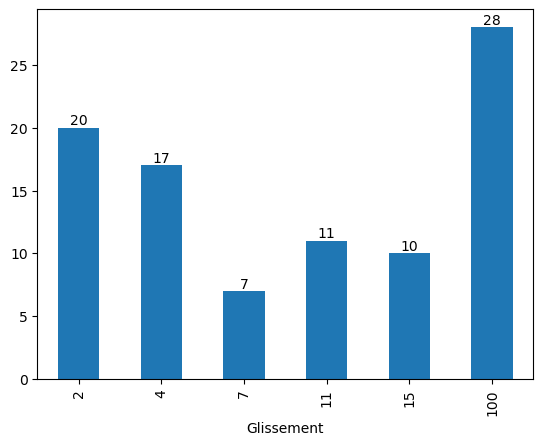

In [ ]:
count_df = slush[slush["Ic G%"] < slush["seuil"]].groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

### Critère 2 (28.5)

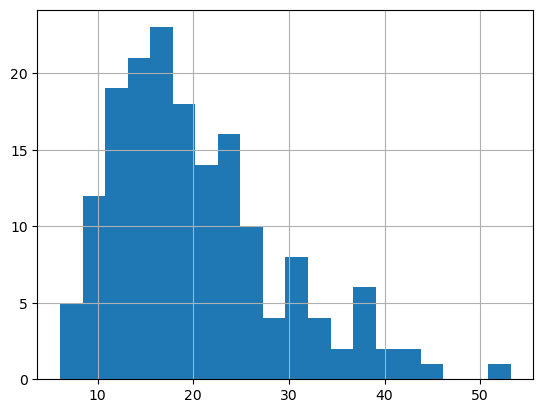

In [ ]:
slush["Ic Fv"].hist(bins = 20)
plt.show()

In [ ]:
slush[slush["Ic Fv"] > 28.5].shape

(28, 9)

On va choisir un seuil de 24

### Critère 3(6)

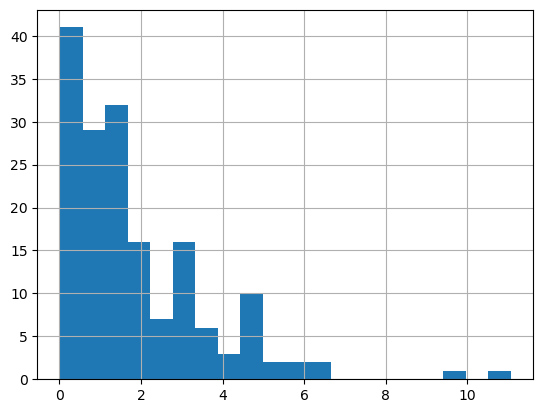

In [ ]:
slush["180 - Fv"].hist(bins = 20)
plt.show()

In [ ]:
slush[slush["180 - Fv"]>6].shape

(4, 9)

La valeur recommandée pour ce seuil est de 6.

### Filtre de validité de SLUSH
Un critère finale de validité de SLUSH est: IC g% < seuil et IC Fv < 28.5 et |180 - Fv| < 6

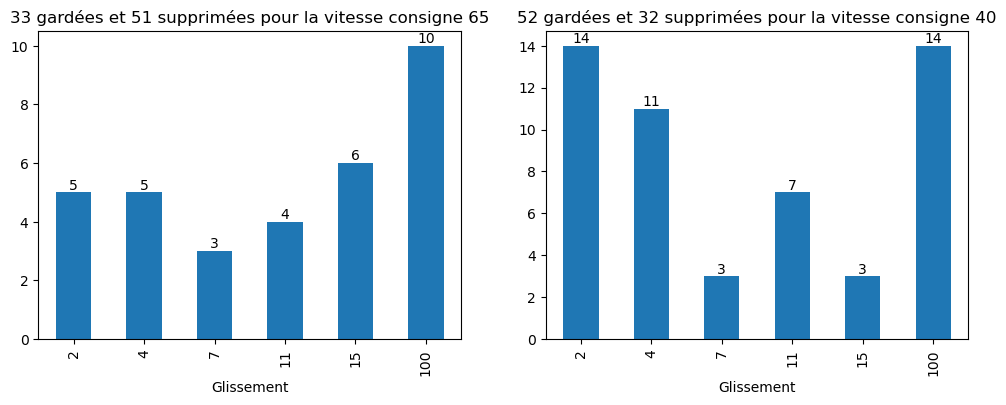

In [ ]:
filtre_3 = (slush["Ic G%"] < slush["seuil"]) & (slush["Ic Fv"] < 28.5) & (slush["180 - Fv"] < 6)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
slush_filtre=slush[slush.Vitesse == 65][filtre_3]
count_df = slush_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{slush_filtre.shape[0]} gardées et {84 -slush_filtre.shape[0]} supprimées pour la vitesse consigne 65")

plt.subplot(1,2,2)
slush_filtre=slush[slush.Vitesse == 40][filtre_3]
count_df = slush_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{slush_filtre.shape[0]} gardées et {84 -slush_filtre.shape[0]} supprimées pour la vitesse consigne 40")
plt.savefig('4.png', dpi=300, bbox_inches='tight')

plt.show()


Validation des Observations en Présence du contaminant Slush

Pour le deuxieme contaminant, Slush, représentant 168 observations dans la base de données initiale, les seuils de validation du glissement sont définis en fonction de la moyenne du pourcentage de glissement (G%).
    
    Pour G% inférieur à 3 : Un seuil strict de 0,5 est appliqué pour assurer une haute précision. Par exemple, avec une moyenne de glissement de 2.5%, seules les valeurs entre 2% et 3% seront considérées comme valides.
    
    Pour G% inférieur à 10 : Un seuil strict de 1.35 est appliqué pour assurer une haute précision. Par exemple, avec une moyenne de glissement de 8%, seules les valeurs entre 6.65% et 9.35% seront considérées comme valides.

    Pour G% entre 10 et 20 : Un seuil de 1,9 est utilisé pour permettre une tolérance modérée. Par exemple, avec une moyenne de glissement de 15%, les valeurs comprises entre 13,1% et 16,9% seront acceptées.

    Pour G% supérieur à 20 : Le seuil est relâché à 5, acceptant de plus grandes variations. Par exemple, avec une moyenne de glissement de 80%, les valeurs entre 75% et 85% seront acceptées.

Autres Critères de Validation

    Pour le deuxième critère : Un seuil de 28.5 est appliqué. Par exemple, lorsque la masse est centrée sur 180 kg, les observations entre 151.5 kg et 208.5 kg seront validées.

    Pour le troisième critère : Un seuil de 6 est choisi. Les valeurs de moyenne des masses entre 174 kg et 186 kg seront tolérées.

Résultats de l'Application des Seuils

Après application de ces seuils, 83 des 186 observations initiales ont été supprimées pour le contaminant slush, réduisant ainsi la moitié des données. Cependant.

## Glace (180 observations)

### Critère 1 (< seuil)

In [ ]:
def seuil(x):
    if x < 10:
        return 0.6
    elif x < 20:
        return 1.5
    else:
        return 5
seuil_glace = lambda x:0.6 if x<10 else (1.5 if x<20 else 5)

In [ ]:
glace = data_seuil[(data_seuil.Contaminant == "Glace")].drop("Contaminant",axis=1)
glace["seuil"] = glace["Moyenne G% [%]"].apply(seuil)

Si le pourcentage de glissement moyen est inférieur à 10%, un seuil strict de 0.6 est appliqué. Si le pourcentage de glissement se situe entre 10% et 20%, le seuil est fixé à 1.5 pour permettre une certaine tolérance. Enfin, pour des pourcentages de glissement supérieurs à 20%, un seuil de 5 est utilisé, permettant d'inclure des observations avec des variations plus importantes.

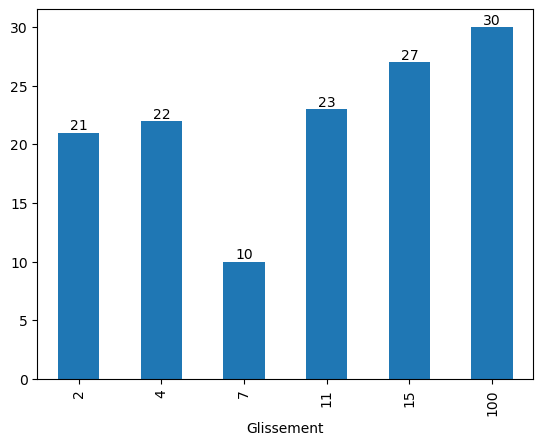

In [ ]:
count_df = glace[glace["Ic G%"] < glace["seuil"]].groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

ce critère est peu pénalisant, parmi 180 observations, on supprime 40 obseravtions, on constate d'apres les graphiques précedentes, une grande variablité pour les petites valeurs du glissement.
Mais la qualité des données est plus importanates que la quantité des données.

### Critère 2  (15)

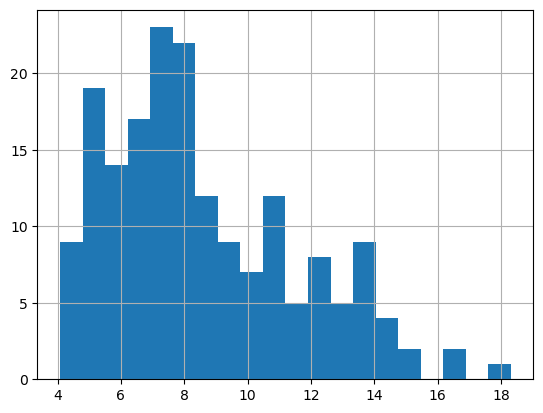

In [ ]:
glace["Ic Fv"].hist(bins = 20)
plt.show()

In [ ]:
glace[glace["Ic Fv"] > 15].shape

(3, 9)

On choisirera 15 comme deuxième seuil.

### Critère 3 (5)

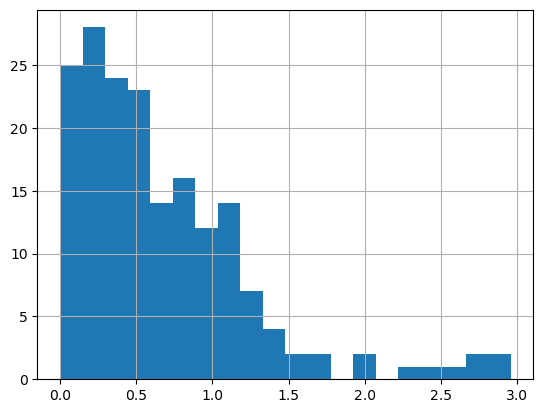

In [ ]:
glace["180 - Fv"].hist(bins = 20)
plt.show()

On choisirera 5 comme troisième seuil.

### filtre de validité de Glace
Un critère finale de validité de glace est: IC g% < seuil et  IC Fv < 15  et  |180 - Fv|  <5  

In [ ]:
dry.Vitesse.value_counts()

Vitesse
40    24
65    24
Name: count, dtype: int64

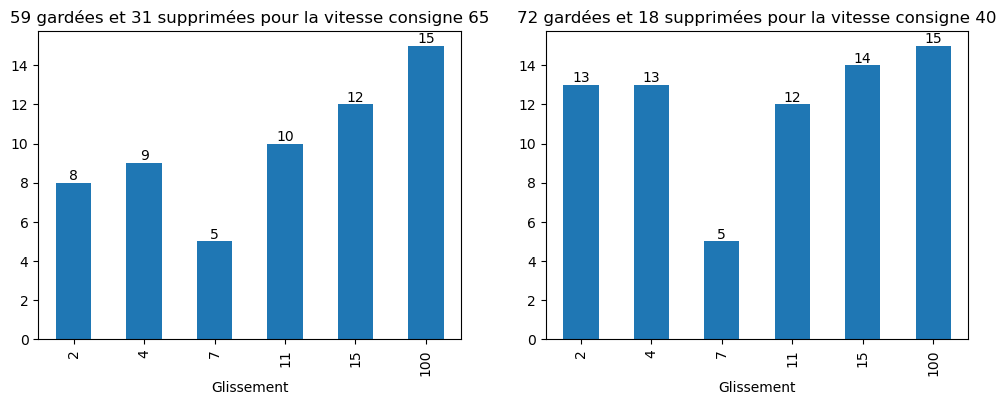

In [ ]:
filtre_4 = (glace["Ic G%"] < glace["seuil"]) & (glace["Ic Fv"] < 15) & (glace["180 - Fv"] < 5)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
glace_filtre=glace[glace.Vitesse == 65][filtre_4]

count_df = glace_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{glace_filtre.shape[0]} gardées et {90 -glace_filtre.shape[0]} supprimées pour la vitesse consigne 65")
plt.subplot(1,2,2)
glace_filtre=glace[glace.Vitesse == 40][filtre_4]

count_df = glace_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{glace_filtre.shape[0]} gardées et {90 -glace_filtre.shape[0]} supprimées pour la vitesse consigne 40")
plt.savefig('5.png', dpi=300, bbox_inches='tight')
plt.show()


Validation des Observations en Présence du contaminant Glace

Pour le troisieme contaminant, Glace, représentant 180 observations dans la base de données initiale, les seuils de validation du glissement sont définis en fonction de la moyenne du pourcentage de glissement (G%).
    
    
    Pour G% inférieur à 10 : Un seuil strict de 0.6 est appliqué pour assurer une haute précision. Par exemple, avec une moyenne de glissement de 7%, seules les valeurs entre 6.4"% et 7.6% seront considérées comme valides.

    Pour G% entre 10 et 20 : Un seuil de 1,5 est utilisé pour permettre une tolérance modérée. Par exemple, avec une moyenne de glissement de 18.5%, les valeurs comprises entre 17% et 20% seront acceptées.

    Pour G% supérieur à 20 : Le seuil est relâché à 5, acceptant de plus grandes variations. Par exemple, avec une moyenne de glissement de 80%, les valeurs entre 75% et 85% seront acceptées.

Autres Critères de Validation

    Pour le deuxième critère : Un seuil de 15 est appliqué. Par exemple, lorsque la masse est centrée sur 180 kg, les observations entre 165 kg et 195 kg seront validées.

    Pour le troisième critère : Un seuil de 5 est choisi. Les valeurs de moyenne des masses entre 175 kg et 185 kg seront tolérées.

Résultats de l'Application des Seuils

Après application de ces seuils, 49 des 180 observations initiales ont été supprimées pour le contaminant slush.

En appliquant ces seuils, sur 180 observations initiales, 49 ont été supprimées. 

## N.C. (G) (217 observations)


### Critère 1 (< seuil)

In [ ]:
def seuil(x):
    if x < 3:
        return 0.4
    if x < 10:
        return 0.9
    elif x < 20:
        return 1.5
    else:
        return 5
seuil_ncg = lambda x:0.4 if x<3 else (0.8 if x<10 else (1.5 if x<20 else 5))


In [ ]:
ncg = data_seuil[(data_seuil.Contaminant == "N.C. (G)")].drop("Contaminant",axis=1)
ncg["seuil"] = ncg["Moyenne G% [%]"].apply(seuil)

Si le pourcentage de glissement moyen est inférieur à 3%, un seuil très strict de 0.4 est appliqué pour garantir une haute précision. Si le pourcentage de glissement est compris entre 3% et 10%, le seuil est augmenté à 0.9, offrant une tolérance modérée. Pour les pourcentages de glissement compris entre 10% et 20%, un seuil de 1.5 est utilisé, permettant une plus grande flexibilité. Enfin, pour des glissements supérieurs à 20%, un seuil de 5 est appliqué, acceptant des variations significatives.

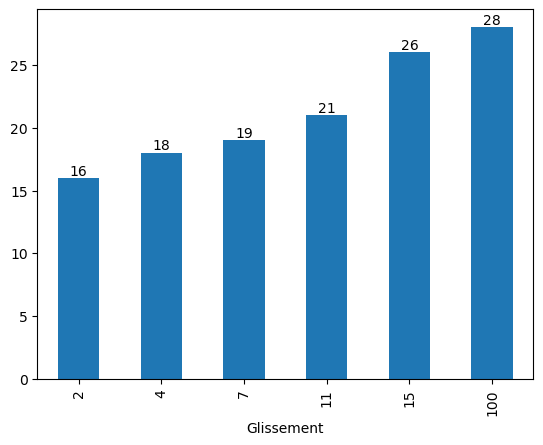

In [ ]:
count_df = ncg[ncg["Ic G%"] < ncg["seuil"]].groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

Ce critère est tres pénalisant, parmi 280 observations, on supprime 90 obseravtions, on constate d'apres les graphiques précedentes, une grande variablité pour les petites valeurs du glissement.
Mais la qualité des données est plus importanates que la quantité des données.

### Critère 2 (18)

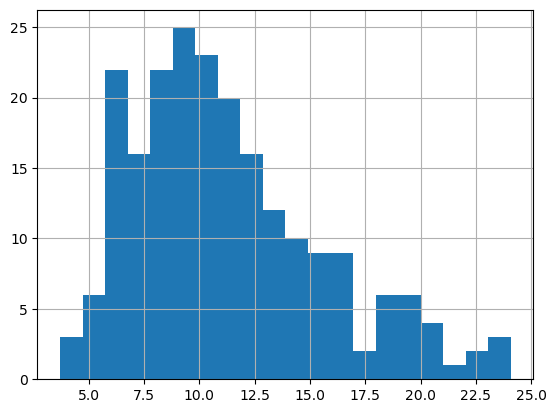

In [ ]:
ncg["Ic Fv"].hist(bins = 20)
plt.show()

In [ ]:
ncg[ncg["Ic Fv"] > 18].shape

(21, 9)

On choisit un seuil de 18.

### Critère 3 (6)

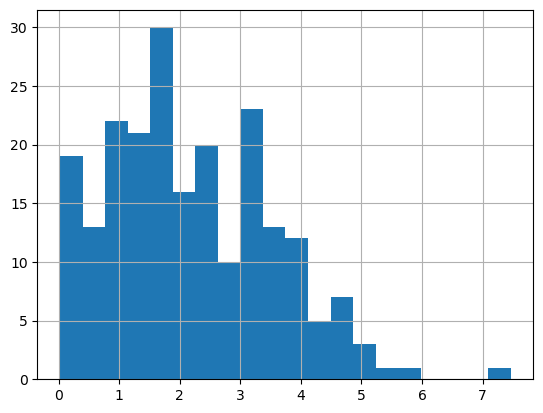

In [ ]:
ncg["180 - Fv"].hist(bins = 20)
plt.show()

In [ ]:
ncg[ncg["180 - Fv"]>6].shape

(1, 9)

On choisirera 6 comme troisieme seuil.

### filtre de validité de ncg
Un critère finale de validité du contaminant ncg est: IC g% < seuil et  IC Fv < 18 et  |180 - Fv|  < 6  

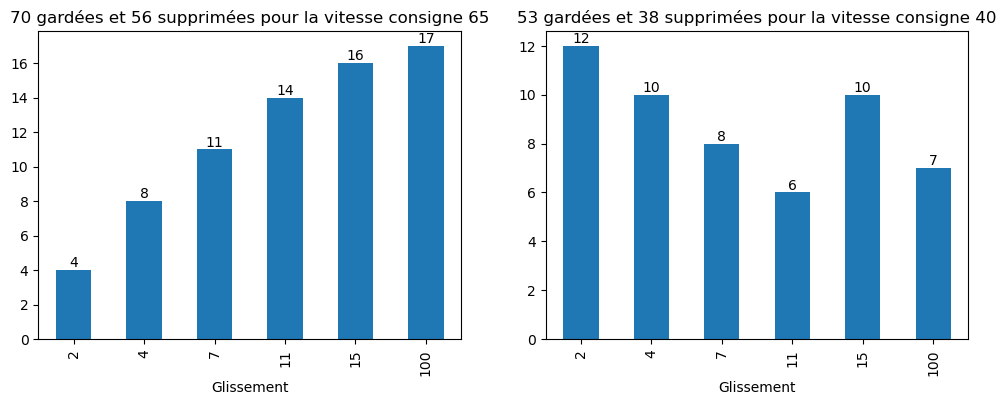

In [ ]:
filtre_5 = (ncg["Ic G%"] < ncg["seuil"]) & (ncg["Ic Fv"] < 18) & (ncg["180 - Fv"] < 6)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)

ncg_filtre=ncg[ncg.Vitesse == 65][filtre_5]

count_df = ncg_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{ncg_filtre.shape[0]} gardées et {126 -ncg_filtre.shape[0]} supprimées pour la vitesse consigne 65")


plt.subplot(1,2,2)
ncg_filtre=ncg[ncg.Vitesse == 40][filtre_5]

count_df = ncg_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{ncg_filtre.shape[0]} gardées et {91 -ncg_filtre.shape[0]} supprimées pour la vitesse consigne 40")
plt.savefig('6.png', dpi=300, bbox_inches='tight')

plt.show()


En appliquant ces seuils, sur 217 observations initiales, 94 ont été supprimées. 

Validation des Observations en Présence du contaminant N.C. (G)

Pour le contaminant, N.C. (G), représentant 217 observations dans la base de données initiale, les seuils de validation du glissement sont définis en fonction de la moyenne du pourcentage de glissement (G%).
    
    Pour G% inférieur à 3 : Un seuil strict de 0,4 est appliqué pour assurer une haute précision. Par exemple, avec une moyenne de glissement de 1.5%, seules les valeurs entre 1.1% et 1.9% seront considérées comme valides.
    
    Pour G% inférieur à 10 : Un seuil strict de 0.9 est appliqué pour assurer une haute précision. Par exemple, avec une moyenne de glissement de 8%, seules les valeurs entre 7.1% et 8.9% seront considérées comme valides.

    Pour G% entre 10 et 20 : Un seuil de 1,5 est utilisé pour permettre une tolérance modérée. Par exemple, avec une moyenne de glissement de 17%, les valeurs comprises entre 15.5% et 18.5% seront acceptées.

    Pour G% supérieur à 20 : Le seuil est relâché à 5, acceptant de plus grandes variations. Par exemple, avec une moyenne de glissement de 80%, les valeurs entre 75% et 85% seront acceptées.

Autres Critères de Validation

    Pour le deuxième critère : Un seuil de 18 est appliqué. Par exemple, lorsque la masse est centrée sur 180 kg, les observations entre 152 kg et 298 kg seront validées.

    Pour le troisième critère : Un seuil de 6 est choisi. Les valeurs de moyenne des masses entre 174 kg et 186 kg seront tolérées.

Résultats de l'Application des Seuils

Après application de ces seuils, 94 des 217 observations initiales ont été supprimées pour le contaminant N.C. (G).

## N.C. (B) (217 observations)

### Critère 1 (< seuil)

In [ ]:
def seuil(x):
    if x < 3:
        return 0.25
    if x < 10:
        return 0.7
    elif x < 20:
        return 1.3
    else:
        return 5
seuil_ncb = lambda x:0.25 if x<3 else (0.7 if x<10 else (1.3 if x<20 else 5))

In [ ]:
ncb = data_seuil[(data_seuil.Contaminant == "N.C. (B)")].drop("Contaminant",axis=1)
ncb["seuil"] = ncb["Moyenne G% [%]"].apply(seuil)

Si le pourcentage de glissement moyen est inférieur à 3%, un seuil très strict de 0.25 est appliqué pour assurer une haute précision. Pour un pourcentage de glissement compris entre 3% et 10%, le seuil est augmenté à 0.7, permettant une tolérance modérée. Pour des glissements compris entre 10% et 20%, le seuil est fixé à 1.3, offrant une plus grande flexibilité. Enfin, pour des glissements supérieurs à 20%, un seuil de 5 est utilisé, acceptant des variations plus importantes.

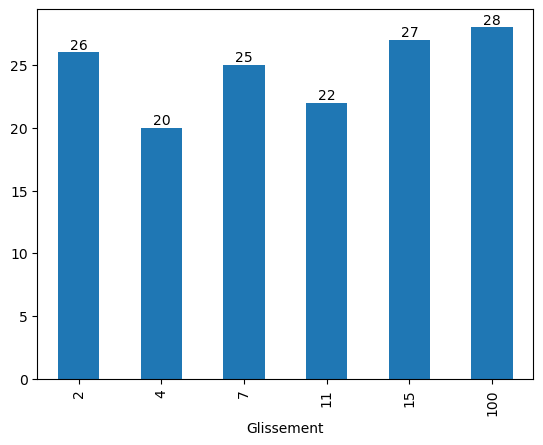

In [ ]:
count_df = ncb[ncb["Ic G%"] < ncb["seuil"]].groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

Ce critère est pénalisant, parmi 217 observations, on supprime 51 obseravtions, on constate d'apres les graphiques précedentes, une grande variablité pour les petites valeurs du glissement.

### Critère 2 (15)

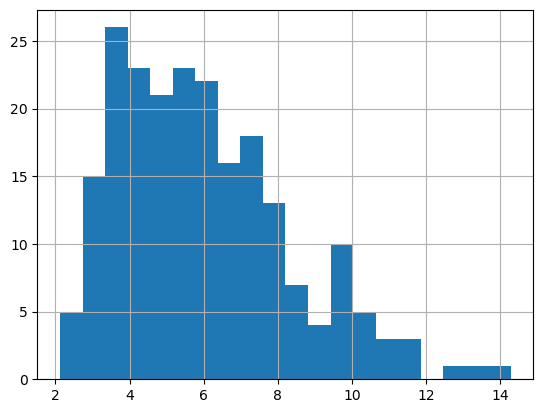

In [ ]:
ncb["Ic Fv"].hist(bins = 20)
plt.show()

In [ ]:
ncb[ncb["Ic Fv"] > 15].shape

(0, 9)

On choisirera 15 comme deuxième seuil.

### Critère 3 (5)

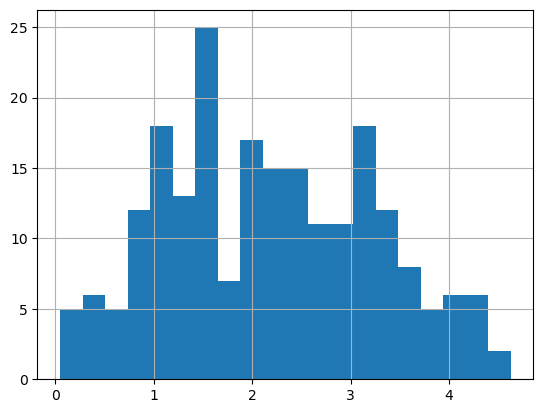

In [ ]:
ncb["180 - Fv"].hist(bins = 20)
plt.show()

In [ ]:
ncb[ncb["180 - Fv"]>5].shape

(0, 9)

On choisirera 5 comme troisième seuil.

### filtre de validité de ncb
Un critère finale de validité du contaminant ncb est: IC g% < seuil et IC Fv < 15 et |180 - Fv| < 5

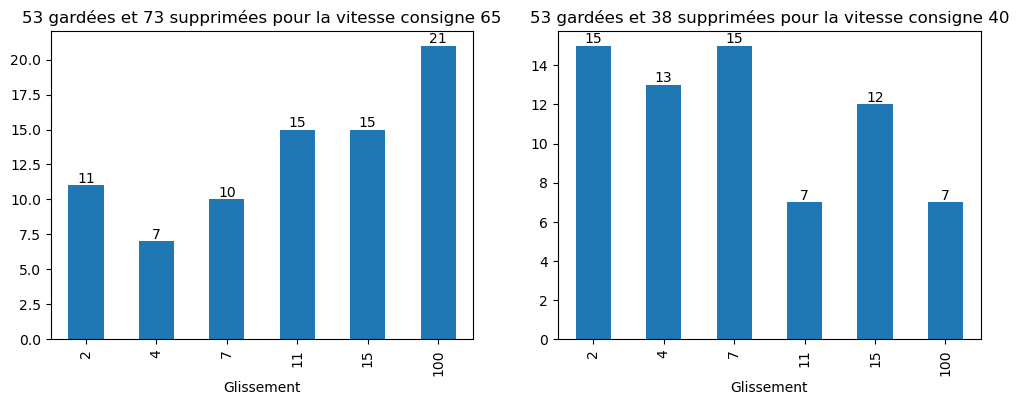

In [ ]:
filtre_6 = (ncb["Ic G%"] < ncb["seuil"]) & (ncb["Ic Fv"] < 15) &(ncb["180 - Fv"] < 5)
plt.figure(figsize=(12,4))


plt.subplot(1,2,1)
ncb_filtre=ncb[ncb.Vitesse == 65][filtre_6]
count_df = ncb_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{ncg_filtre.shape[0]} gardées et {126 -ncg_filtre.shape[0]} supprimées pour la vitesse consigne 65")

plt.subplot(1,2,2)
ncb_filtre=ncb[ncb.Vitesse == 40][filtre_6]
count_df = ncb_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{ncg_filtre.shape[0]} gardées et {91 -ncg_filtre.shape[0]} supprimées pour la vitesse consigne 40")

plt.savefig('7.png', dpi=300, bbox_inches='tight')

plt.show()


En appliquant ces seuils, sur 217 observations initiales, 69 ont été supprimées. 

Validation des Observations en Présence du contaminant N.C. (B)

Pour le contaminant, N.C. (B), représentant 217 observations dans la base de données initiale, les seuils de validation du glissement sont définis en fonction de la moyenne du pourcentage de glissement (G%).
    
    Pour G% inférieur à 3 : Un seuil strict de 0,25 est appliqué pour assurer une haute précision. Par exemple, avec une moyenne de glissement de 2.5%, seules les valeurs entre 2.75% et 2.25% seront considérées comme valides.
    
    Pour G% inférieur à 10 : Un seuil strict de 0.7 est appliqué pour assurer une haute précision. Par exemple, avec une moyenne de glissement de 9%, seules les valeurs entre 8.3% et 9.7% seront considérées comme valides.

    Pour G% entre 10 et 20 : Un seuil de 1,3 est utilisé pour permettre une tolérance modérée. Par exemple, avec une moyenne de glissement de 14%, les valeurs comprises entre 12.7% et 15.3% seront acceptées.

    Pour G% supérieur à 20 : Le seuil est relâché à 5, acceptant de plus grandes variations. Par exemple, avec une moyenne de glissement de 80%, les valeurs entre 75% et 85% seront acceptées.

Autres Critères de Validation

    Pour le deuxième critère : Un seuil de 15 est appliqué. Par exemple, lorsque la masse est centrée sur 180 kg, les observations entre 155 kg et 295 kg seront validées.

    Pour le troisième critère : Un seuil de 5 est choisi. Les valeurs de moyenne des masses entre 175 kg et 185 kg seront tolérées.

Résultats de l'Application des Seuils

Après application de ces seuils, 69 des 217 observations initiales ont été supprimées pour le contaminant N.C. (B).

In [ ]:
ncb.Vitesse.value_counts()

Vitesse
65    126
40     91
Name: count, dtype: int64

## NC.C. (540 observations)

### Critère 1 ( < seuil)

In [ ]:
def seuil(x):
    if x < 3:
        return 0.4
    if x < 10:
        return 0.8
    elif x < 20:
        return 1.5
    else:
        return 5
seuil_ncc = lambda x:0.4 if x<3 else (0.8 if x<10 else (1.5 if x<20 else 5))

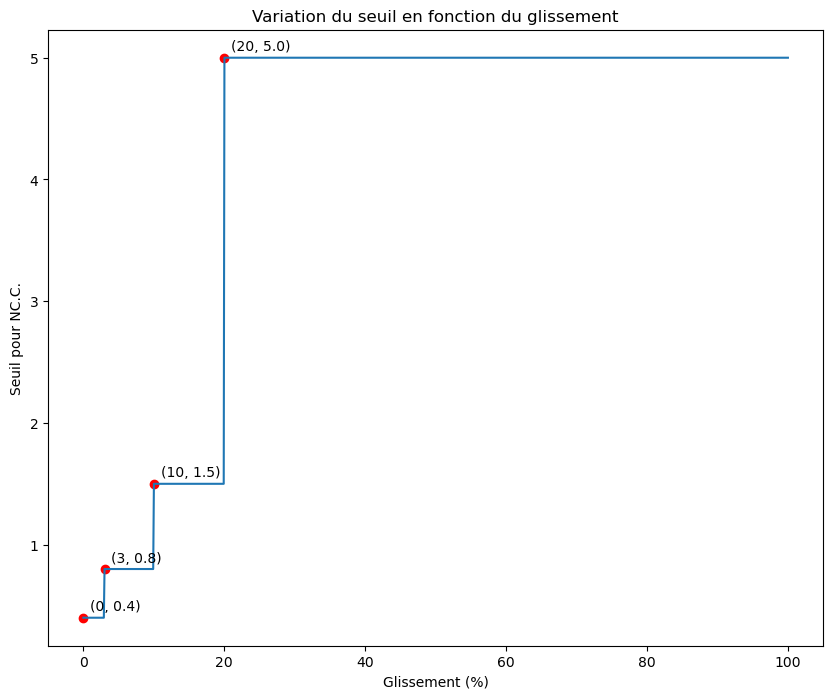

In [ ]:
plt.figure(figsize=(10,8))
glissements_specifiques = [0, 3, 10, 20]
seuils_specifiques = [seuil(g) for g in glissements_specifiques]

# Tracé des points spécifiques
plt.plot(glissements_specifiques, seuils_specifiques, 'ro', label='Points spécifiques')

# Tracé de la courbe pour toutes les valeurs de glissement
x = np.linspace(0, 100, 1000)
y = [seuil(g) for g in x]
plt.plot(x, y, label='Seuil')

# Annoter chaque point spécifique
for g, s in zip(glissements_specifiques, seuils_specifiques):
    plt.annotate(f"({g}, {s:.1f})", xy=(g, s), xytext=(5, 5), textcoords='offset points')

# Configuration du graphique
plt.xlabel("Glissement (%)")
plt.ylabel("Seuil pour NC.C.")
plt.title("Variation du seuil en fonction du glissement")
plt.show()

In [ ]:
ncc = data_seuil[(data_seuil.Contaminant == "NC.C.")].drop("Contaminant",axis=1)
ncc["seuil"] = ncc["Moyenne G% [%]"].apply(seuil)

Si le pourcentage de glissement moyen est inférieur à 3%, un seuil strict de 0.4 est appliqué pour assurer une haute précision. Si le pourcentage de glissement est compris entre 3% et 10%, le seuil est augmenté à 0.8, permettant une tolérance modérée. Pour des pourcentages de glissement compris entre 10% et 20%, un seuil de 1.5 est utilisé, offrant une plus grande flexibilité. Enfin, pour des glissements supérieurs à 20%, un seuil de 5 est appliqué, acceptant des variations significatives.

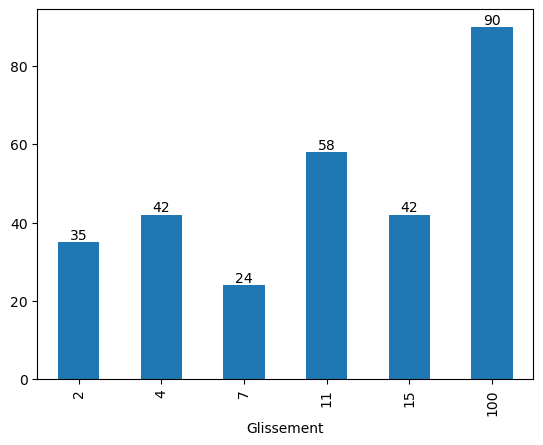

In [ ]:
count_df = ncc[ncc["Ic G%"] < ncc["seuil"]].groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

### Critère 2 (16)

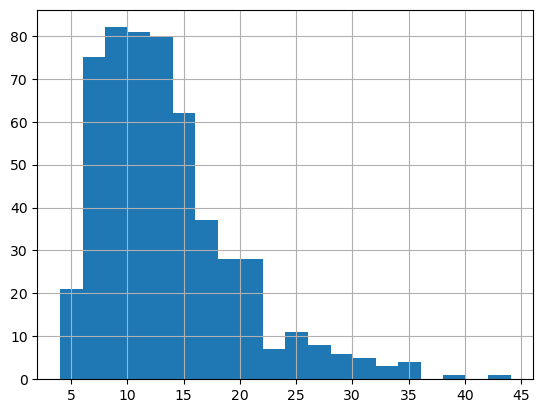

In [ ]:
ncc["Ic Fv"].hist(bins = 20)
plt.show()

In [ ]:
ncg[ncg["Ic Fv"] > 16].shape

(33, 9)

On choisit un seuil de 16

### Critère 3 (5)

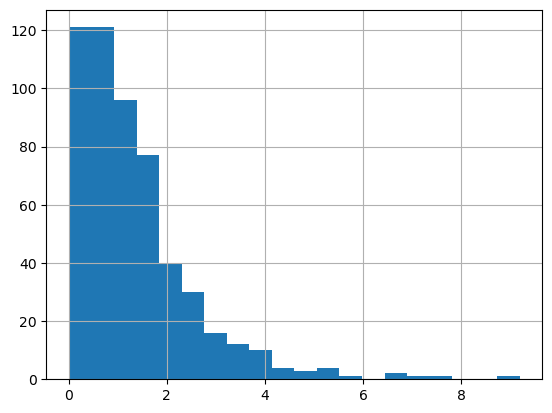

In [ ]:
ncc["180 - Fv"].hist(bins = 20)
plt.show()

In [ ]:
ncc[ncc["180 - Fv"]>5].shape

(10, 9)

On choisirera 15 comme troisieme seuil.

### filtre de validité de ncc
Un critère finale de validité du contaminant ncb est: IC g% < seuil*g et IC Fv < 17 et |180 - Fv| < 5

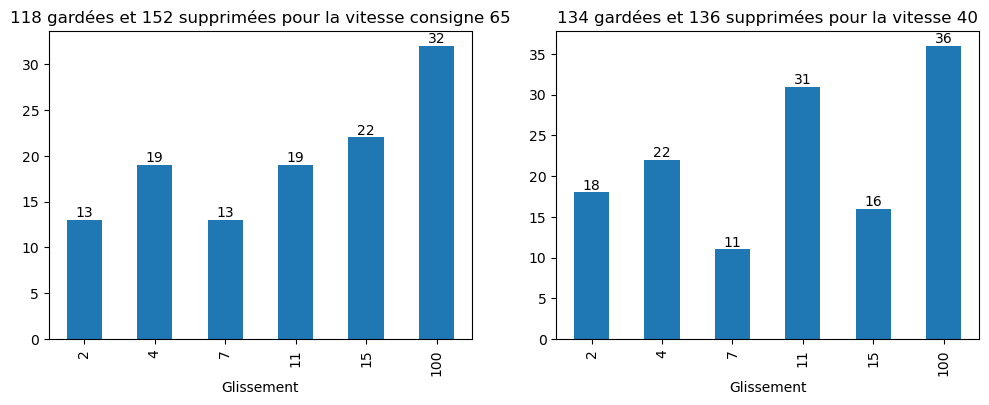

In [ ]:
filtre_7 = (ncc["Ic G%"] < ncc["seuil"]) & (ncc["Ic Fv"] < 16) & (ncc["180 - Fv"] < 5)
plt.figure(figsize=(12,4))


plt.subplot(1,2,1)
ncc_filtre=ncc[ncc.Vitesse == 65][filtre_7]
count_df = ncc_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{ncc_filtre.shape[0]} gardées et {270 -ncc_filtre.shape[0]} supprimées pour la vitesse consigne 65")


plt.subplot(1,2,2)
ncc_filtre=ncc[ncc.Vitesse == 40][filtre_7]
count_df = ncc_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{ncc_filtre.shape[0]} gardées et {270 -ncc_filtre.shape[0]} supprimées pour la vitesse 40")
plt.savefig('8.png', dpi=300, bbox_inches='tight')

plt.show()


Validation des Observations en Présence du contaminant NC.C.

Pour le contaminant, NC.C., représentant 540 observations dans la base de données initiale, les seuils de validation du glissement sont définis en fonction de la moyenne du pourcentage de glissement (G%).
    
    Pour G% inférieur à 3 : Un seuil strict de 0,4 est appliqué pour assurer une haute précision.
    Pour G% inférieur à 10 : Un seuil strict de 0.8 est appliqué pour assurer une haute précision.
    Pour G% entre 10 et 20 : Un seuil de 1,5 est utilisé pour permettre une tolérance modérée.
    Pour G% supérieur à 20 : Le seuil est relâché à 5, acceptant de plus grandes variations.

Autres Critères de Validation

    Pour le deuxième critère : Un seuil de 16 est appliqué.
    Pour le troisième critère : Un seuil de 5 est choisi.

Résultats de l'Application des Seuils

En appliquant ces seuils, sur 540 observations initiales, 288 ont été supprimées (plus que la moitié). 

## Neige fraiche (B) (337 observations)

### Critère 1 (< seuil)

In [ ]:
def seuil(x):
    if x < 3:
        return 0.5 #ancien 0.3
    if x < 10:
        return 0.8# ancien 0.5
    elif x < 20:
        return 1.4
    else:
        return 5
seuil_nfb = lambda x:0.3 if x<3 else (0.7 if x<10 else (1.4 if x<20 else 5))

In [ ]:
nfb = data_seuil[(data_seuil.Contaminant == "Neige fraiche (B)")].drop("Contaminant",axis=1)
nfb["seuil"] = nfb["Moyenne G% [%]"].apply(seuil)

Si le pourcentage de glissement moyen est inférieur à 3%, un seuil strict de 0.3 est appliqué pour assurer une haute précision. Pour un pourcentage de glissement compris entre 3% et 10%, le seuil est augmenté à 0.7, permettant une tolérance modérée. Pour des glissements compris entre 10% et 20%, le seuil est fixé à 1.4, offrant une plus grande flexibilité. Enfin, pour des glissements supérieurs à 20%, un seuil de 5 est utilisé, acceptant des variations plus importantes.

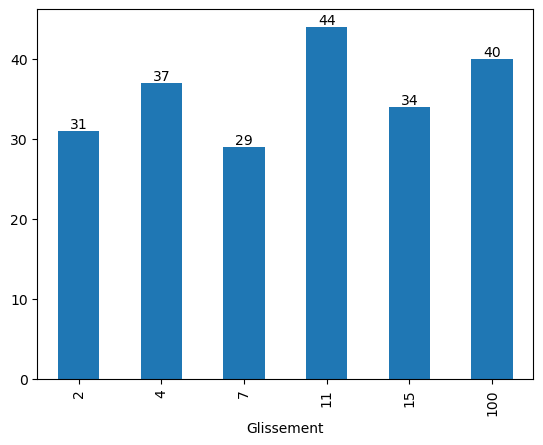

In [ ]:
count_df = nfb[nfb["Ic G%"] < nfb["seuil"]].groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

### Critère 2 (15)

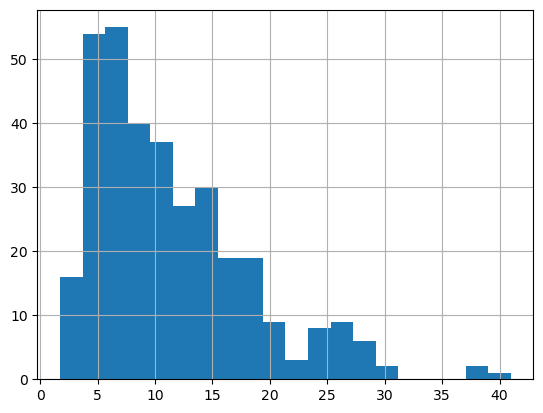

In [ ]:
nfb["Ic Fv"].hist(bins = 20)
plt.show()

In [ ]:
nfb[nfb["Ic Fv"] > 15].shape

(85, 9)

On choisirera 15 comme deuxième seuil.

### Critère 3 (5)

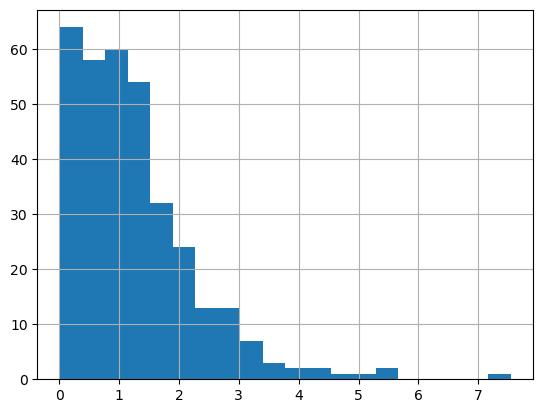

In [ ]:
nfb["180 - Fv"].hist(bins = 20)
plt.show()

In [ ]:
nfb[nfb["180 - Fv"]>5].shape

(3, 9)

Un seuil de 5 est choisit comme troisième critère.

### filtre de validité de nfb
Un critère finale de validité du contaminant nfb est: IC g% < seuil et IC Fv < 15 et |180 - Fv| < 5

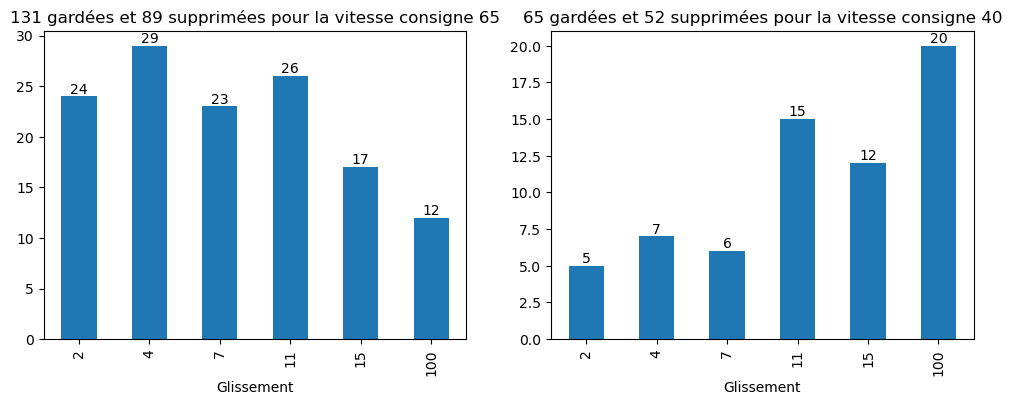

In [ ]:
filtre_8 = (nfb["Ic G%"] < nfb["seuil"]) & (nfb["Ic Fv"] < 15) & (nfb["180 - Fv"] < 5)

plt.figure(figsize=(12,4))


plt.subplot(1,2,1)
nfb_filtre=nfb[nfb.Vitesse == 65][filtre_8]
count_df = nfb_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{nfb_filtre.shape[0]} gardées et {220 -nfb_filtre.shape[0]} supprimées pour la vitesse consigne 65")

plt.subplot(1,2,2)
nfb_filtre=nfb[nfb.Vitesse == 40][filtre_8]
count_df = nfb_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{nfb_filtre.shape[0]} gardées et {117 -nfb_filtre.shape[0]} supprimées pour la vitesse consigne 40")

plt.savefig('9.png', dpi=300, bbox_inches='tight')

plt.show()


Validation des Observations en Présence du contaminant Neige fraiche (B)

Pour le contaminant, Neige fraiche (B), représentant 337 observations dans la base de données initiale, les seuils de validation du glissement sont définis en fonction de la moyenne du pourcentage de glissement (G%).
    
    Pour G% inférieur à 3 : Un seuil strict de 0,5 est appliqué pour assurer une haute précision.
    Pour G% inférieur à 10 : Un seuil strict de 0.8 est appliqué pour assurer une haute précision.
    Pour G% entre 10 et 20 : Un seuil de 1,4 est utilisé pour permettre une tolérance modérée.
    Pour G% supérieur à 20 : Le seuil est relâché à 5, acceptant de plus grandes variations.

Autres Critères de Validation

    Pour le deuxième critère : Un seuil de 15 est appliqué.
    Pour le troisième critère : Un seuil de 5 est choisi.

Résultats de l'Application des Seuils

En appliquant ces seuils, sur 337 observations initiales pour le contaminant Neige fraiche (B), 141 ont été supprimées. 

## Neige fraiche (G) (306 observations)

### Critère 1 (< seuil)

In [ ]:
def seuil(x):
    if x < 3:
        return 0.4
    if x < 10:
        return 0.8
    elif x < 20:
        return 1.4
    else:
        return 5
seuil_nfg = lambda x:0.4 if x<3 else (0.8 if x<10 else (1.4 if x<20 else 5))

In [ ]:
nfg = data_seuil[(data_seuil.Contaminant == "Neige fraiche (G)")].drop("Contaminant",axis=1)
nfg["seuil"] = nfg["Moyenne G% [%]"].apply(seuil)

Si le pourcentage de glissement moyen est inférieur à 3%, un seuil strict de 0.4 est appliqué pour assurer une haute précision. Pour un pourcentage de glissement compris entre 3% et 10%, le seuil est augmenté à 0.8, permettant une tolérance modérée. Pour des pourcentages de glissement compris entre 10% et 20%, un seuil de 1.4 est utilisé, offrant une plus de flexibilité. Enfin, pour des glissements supérieurs à 20%, un seuil de 5 est appliqué, acceptant des variations significatives.

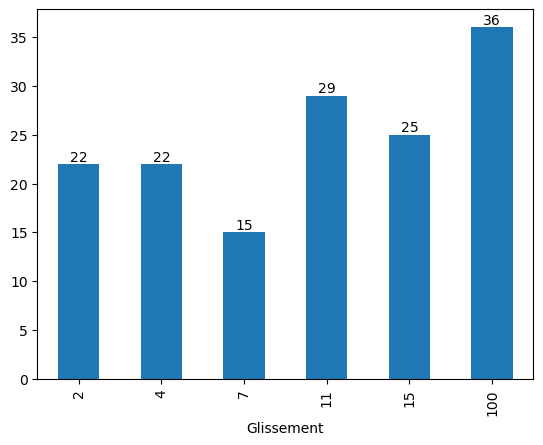

In [ ]:
count_df = nfg[nfg["Ic G%"] < nfg["seuil"]].groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

Ce critère est tres pénalisant, parmi 306 observations, on supprime 140 obseravtions, on constate d'apres les graphiques précedentes, une grande variablité pour les petites valeurs du glissement.

### Critère 2 (15)


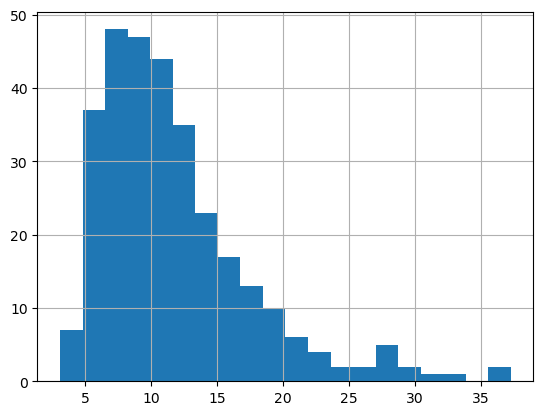

In [ ]:
nfg["Ic Fv"].hist(bins = 20)
plt.show()

In [ ]:
nfg[nfg["Ic Fv"] > 15].shape

(66, 9)

On choisirera 15 comme deuxième seuil.

### Critère 3 (5)

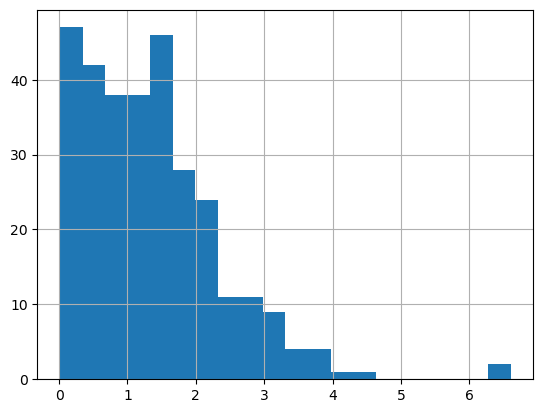

In [ ]:
nfg["180 - Fv"].hist(bins = 20)
plt.show()

In [ ]:
nfg[nfg["180 - Fv"]>5].shape

(2, 9)

Pour ce seuil, 5 est choisit.

### filtre de validité de nfg
Un critre finale de validité du contaminant ncb est: IC g% < seuil et IC Fv < 15 et |180 - Fv| < 5

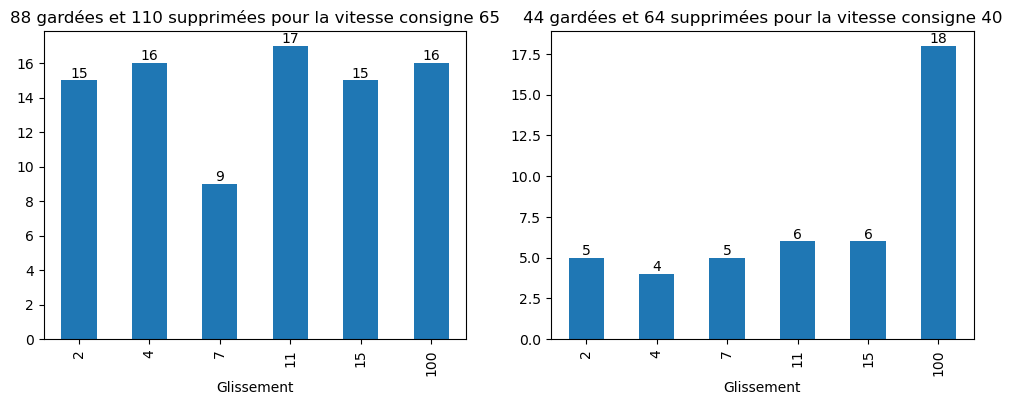

In [ ]:
filtre_9 = (nfg["Ic G%"] < nfg["seuil"]) & (nfg["Ic Fv"] < 15)  & (nfg["180 - Fv"] < 5)
plt.figure(figsize=(12,4))


plt.subplot(1,2,1)
nfg_filtre=nfg[nfg.Vitesse == 65][filtre_9]

count_df = nfg_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{nfg_filtre.shape[0]} gardées et {198 -nfg_filtre.shape[0]} supprimées pour la vitesse consigne 65")


plt.subplot(1,2,2)
nfg_filtre=nfg[nfg.Vitesse == 40][filtre_9]
count_df = nfg_filtre.groupby(['Glissement'])['Glissement'].agg("count")
ax = count_df.plot(kind='bar')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.title(f"{nfg_filtre.shape[0]} gardées et {108 -nfg_filtre.shape[0]} supprimées pour la vitesse consigne 40")
plt.savefig('10.png', dpi=300, bbox_inches='tight')

plt.show()


Validation des Observations en Présence du contaminant Neige fraiche (G)

Pour le contaminant, Neige fraiche (G), représentant 306 observations dans la base de données initiale, les seuils de validation du glissement sont définis en fonction de la moyenne du pourcentage de glissement (G%).
    
    Pour G% inférieur à 3 : Un seuil strict de 0,4 est appliqué pour assurer une haute précision.
    Pour G% inférieur à 10 : Un seuil strict de 0.8 est appliqué pour assurer une haute précision.
    Pour G% entre 10 et 20 : Un seuil de 1,4 est utilisé pour permettre une tolérance modérée.
    Pour G% supérieur à 20 : Le seuil est relâché à 5, acceptant de plus grandes variations.

Autres Critères de Validation

    Pour le deuxième critère : Un seuil de 15 est appliqué.
    Pour le troisième critère : Un seuil de 5 est choisi.

Résultats de l'Application des Seuils

En appliquant ces seuils, sur 306 observations initiales pour le contaminant Neige fraiche (G), 174 ont été supprimées. 

En appliquant ces seuils, sur 306 observations initiales, 174 ont été supprimées. 

In [ ]:
nfg.Vitesse.value_counts()

Vitesse
65    198
40    108
Name: count, dtype: int64

## DRY (48 observations)


In [ ]:
def seuil(x):
    if x < 10:
        return 0.8
    elif x < 20:
        return 1.6
    else:
        return 5
dry = data_seuil[(data_seuil.Contaminant == "DRY")].drop("Contaminant",axis=1)
dry["seuil"] = dry["Moyenne G% [%]"].apply(seuil)
dry


,Vitesse,Glissement,Fv (kg),Moyenne G% [%],ET G%,Ic G%,Ic Fv,180 - Fv,seuil
1621,40,2,180.178095,3.344762,4.252520,1.983561,4.297307,0.178095,0.8
1622,40,2,179.849048,0.746667,0.189376,0.088333,3.029070,0.150952,0.8
1631,40,4,180.582381,5.913333,5.845434,2.726566,4.630790,0.582381,0.8
1632,40,4,180.085714,3.803333,3.914822,1.826044,3.639718,0.085714,0.8
1641,40,7,180.530000,8.750952,7.430807,3.466054,4.559638,0.530000,0.8
1642,40,7,180.167619,6.974762,3.750922,1.749594,4.638196,0.167619,0.8
1651,40,11,180.220476,12.782381,8.675250,4.046516,5.834050,0.220476,1.6
1652,40,11,179.724762,11.017619,5.876108,2.740874,3.468335,0.275238,1.6
1661,40,15,179.868095,16.222857,8.704051,4.059951,5.316229,0.131905,1.6
1662,40,15,179.826190,14.870000,6.130670,2.859613,2.751125,0.173810,1.6


### Critère 1 (< seuil)

In [ ]:
dry[dry["Ic G%"]>dry["seuil"]].shape

(29, 9)

ce critère est tres pénalisant, parmi 48 observations, on supprime 38 obseravtions, on constate d'apres les les graphiques précedentes, une grande variablité pour les petites valeurs du glissement. Mais la qualité des données est plus importanates que la quantité des données.
Pour ce premier critère on a supprimé 38 observations, il vaut mieux de supprimer ce contaminant tres instable.

### Critère 2 (15)

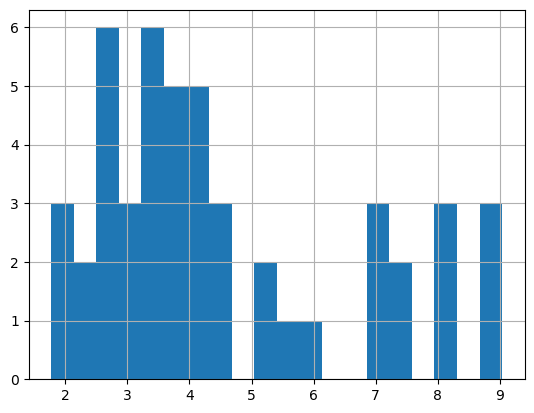

In [ ]:
dry["Ic Fv"].hist(bins = 20)
plt.show()

Le seuil 15 n'a supprimé aucune valeur, car la plus grande valeur pour ce critère dans cette classe est inférieure à 9.


### Critère 3 (5)

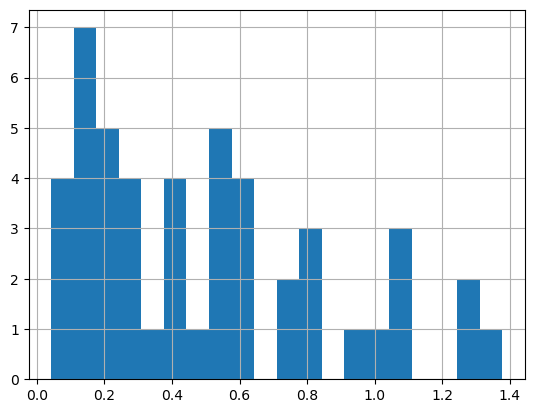

In [ ]:
dry["180 - Fv"].hist(bins = 20)
plt.show()

Le dernier critère n'a supprimé aucune valeur, car la plus grande valeur pour ce critère dans cette classe est inférieure à 1,4.

### filtre de validité de DRY
Un critère finale de validité de verglas est: IC g% < 1.8 et  IC Fv < 15  et   |glissement - glissment_moy| < 1.5  et  |180 - Fv|  <5  

In [ ]:
filtre_2 = (dry["Ic G%"] < dry["seuil"]) & (dry["Ic Fv"] < 15) & (dry["180 - Fv"] < 5)
dry_filtre=dry[filtre_2]
dry_filtre.shape


(19, 9)

Les resultats de la modélisation de CFL C sur le contaminant DRY, n'auront aucun sens avec 10 obsevations.

Il reste 2 observations pour le dry Mdr.

# Fin de la recherche des seuils